# Cost Analysis (cost_001)

48 journey configurations (2 directions x 2 speeds x 12 months) with production
hyperparameters. Multiple replicas per journey across submissions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from load_results import (
    load_results,
    filter_kinked_routes,
    get_journey_params_df,
    get_hyper_params_df,
    get_elite_df,
    get_runtime_df,
    add_derived_features,
    filter_suspicious_routes,
)
from experiment_params import (
    REPRESENTATIVE_CASES,
    ROUTES,
)

## 1. Load & merge results

In [2]:
result_files = sorted(Path("../results").glob("cost_*.msgpack"))
print(f"Found {len(result_files)} result files")
for f in result_files:
    print(f"  {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

Found 2 result files
  cost_sub01_20260211_163739.msgpack (3.8 MB)
  cost_sub02_20260211_164705.msgpack (3.5 MB)


In [3]:
# Load all results (dedup by key across files)
rr_dict = load_results(result_files)
print(f"Loaded {len(rr_dict)} unique results")

# Remove routes with crossover kinks (max turning angle > 60°)
rr_dict = filter_kinked_routes(rr_dict)
print(f"After kink filter: {len(rr_dict)} results")

records:   0%|          | 0/405 [00:00<?, ?it/s]

Loaded 405 unique results
45/405 routes removed (max turning angle > 60.0°)
After kink filter: 360 results


In [4]:
# Extract DataFrames
journey_df = get_journey_params_df(rr_dict)
hyper_df = get_hyper_params_df(rr_dict)
elite_df = get_elite_df(rr_dict)
runtime_df = get_runtime_df(rr_dict)

# Merge (keep only best elite per result)
elite_best = elite_df[elite_df.n_elite == 0].copy()
df = journey_df.join(hyper_df).join(elite_best).join(runtime_df)
df = add_derived_features(df)

print(f"Combined DataFrame: {len(df)} rows")
df.head()

elite:   0%|          | 0/360 [00:00<?, ?it/s]

Combined DataFrame: 360 rows


,journey_name,journey_lon_waypoints,journey_lat_waypoints,journey_time_start,journey_time_end,journey_speed_knots,journey_time_resolution_hours,hyper_population_size,hyper_random_seed,hyper_selection_acceptance_rate_warmup,...,elite_cost_absolute,elite_cost_relative,elite_has_negative_time,geometry,runtime,runtime_seconds,hyper_num_individuals,journey_duration,seed_cost,elite_speed_og_mps_average
filename,,,,,,,,,,,,,,,,,,,,,
result:0027:seed3284611456:hasha5f42390,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-03-01T00:00:00,2021-03-12T10:10:42,12.0,6.0,256,3284611456,0.3,...,6.212020e+14,0.515176,False,"LINESTRING (-80.5 29.999999999999986, -79.4551...",0 days 00:35:12,2112.0,1024,11 days 10:10:42,1.205806e+15,9.041263
result:0045:seed3819685402:hashf7802ecb,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-05-01T00:00:00,2021-05-12T10:10:42,12.0,6.0,256,3819685402,0.3,...,7.936281e+12,0.963040,False,"LINESTRING (-80.5 29.99999999999999, -79.50341...",0 days 00:35:30,2130.0,1024,11 days 10:10:42,8.240865e+12,6.200886
result:0047:seed2203676130:hash964debf6,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-05-01T00:00:00,2021-05-12T10:10:42,12.0,6.0,256,2203676130,0.3,...,7.883276e+12,0.956608,False,"LINESTRING (-80.5 29.99999999999999, -79.50657...",0 days 00:35:38,2138.0,1024,11 days 10:10:42,8.240865e+12,6.232176
result:0076:seed530259931:hash76da9615,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-08-01T00:00:00,2021-08-12T10:10:42,12.0,6.0,256,530259931,0.3,...,4.953289e+12,0.828524,False,"LINESTRING (-80.5 29.99999999999999, -79.48625...",0 days 00:35:57,2157.0,1024,11 days 10:10:42,5.978451e+12,6.229219
result:0036:seed1324309150:hash9ae717bb,Atlantic_forward,"[-80.5, -11.0]","[30.0, 50.0]",2021-04-01T00:00:00,2021-04-12T10:10:42,12.0,6.0,256,1324309150,0.3,...,7.652753e+12,0.885789,False,"LINESTRING (-80.5 29.99999999999999, -79.49023...",0 days 00:36:06,2166.0,1024,11 days 10:10:42,8.639474e+12,6.251522


In [5]:
# Quality filter
df_clean = filter_suspicious_routes(df)
print(f"After filtering: {len(df_clean)} / {len(df)} rows")

2.78% suspicious routes
After filtering: 350 / 360 rows


In [6]:
# Coverage: replicas per journey
df_clean["month"] = pd.to_datetime(df_clean.journey_time_start.astype(str)).dt.month
df_clean["direction"] = df_clean.journey_name.map(
    {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
)
df_clean["speed"] = df_clean.journey_speed_knots.astype(float)

coverage = df_clean.groupby(["direction", "speed", "month"], observed=True).size().unstack(fill_value=0)
print("Replicas per (direction, speed, month):")
coverage

Replicas per (direction, speed, month):


month            1   2   3   4   5   6   7   8   9   10  11  12
direction speed                                                
westward  8.0     5   4   6   4   5   7   6   7   6   9   9   7
          12.0    5   6  10   6   9   9  10   9   8   9   8  10
eastward  8.0     7   7   6   5   6   7   3   6   6   7   6   1
          12.0    9   7   9   8   9   9   9  10   9  10  10  10

## 2. Cost reduction summary

In [7]:
# Cost reduction = 1 - elite_cost_relative (fraction saved vs seed route)
df_clean["cost_reduction"] = 1.0 - df_clean.elite_cost_relative

# Summary stats
print(f"Overall cost reduction: {df_clean.cost_reduction.median():.1%} median, "
      f"{df_clean.cost_reduction.mean():.1%} mean")
print(f"Range: {df_clean.cost_reduction.min():.1%} to {df_clean.cost_reduction.max():.1%}")
print()

# By direction and speed
summary = df_clean.groupby(["direction", "speed"], observed=True).cost_reduction.agg(
    ["count", "median", "mean", "std", "min", "max"]
).round(3)
summary

Overall cost reduction: 31.2% median, 48.2% mean
Range: 1.0% to 98.9%



count  median   mean    std    min    max
direction speed                                           
westward  8.0       75   0.918  0.623  0.403  0.076  0.985
          12.0      99   0.151  0.446  0.414  0.019  0.977
eastward  8.0       67   0.906  0.640  0.360  0.156  0.989
          12.0     109   0.163  0.320  0.275  0.010  0.978

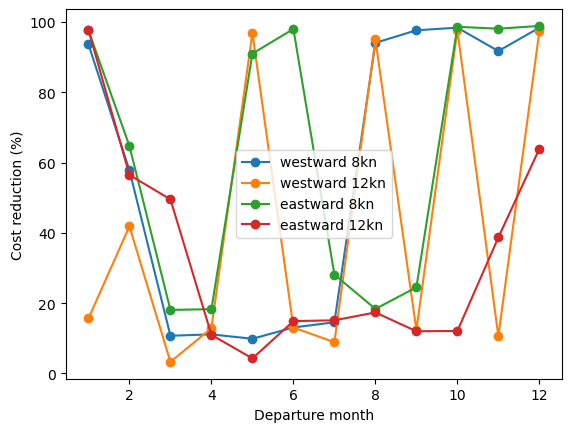

In [8]:
# Median cost reduction by month, pivoted for plotting
reduction_monthly = (
    df_clean.groupby(["direction", "speed", "month"], observed=True)
    .cost_reduction.median()
    .unstack(["direction", "speed"]) * 100
)
reduction_monthly.columns = [f"{d} {s:.0f}kn" for d, s in reduction_monthly.columns]
reduction_monthly.plot(style="o-", ylabel="Cost reduction (%)", xlabel="Departure month")
plt.show()

## 3. Cost spread per case

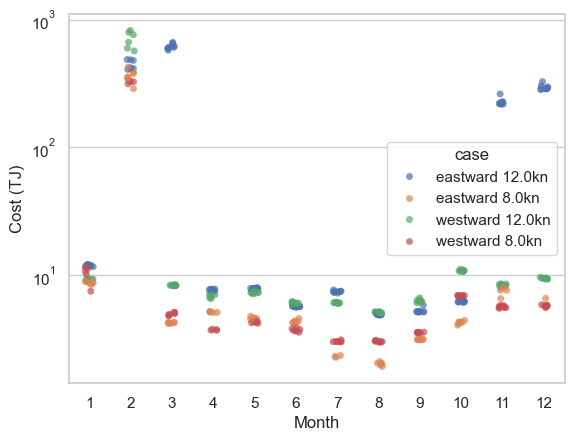

In [9]:
df_clean["cost_TJ"] = df_clean.elite_cost_absolute / 1e12
df_clean["seed_cost_TJ"] = df_clean.seed_cost / 1e12
df_clean["case"] = df_clean.direction.astype(str) + " " + df_clean.speed.astype(str) + "kn"

import seaborn as sns
sns.set_theme(style="whitegrid")
sns.stripplot(data=df_clean, x="month", y="cost_TJ", hue="case", size=5, alpha=0.7)
plt.yscale("log")
plt.ylabel("Cost (TJ)")
plt.xlabel("Month")
plt.show()

In [10]:
# Cost spread (IQR) across replicas per journey
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

spread = df_clean.groupby(["direction", "speed", "month"], observed=True).cost_TJ.agg(
    ["median", "std", "count", iqr]
)
spread["cv"] = spread["std"] / spread["median"]  # coefficient of variation
print("Cost spread across replicas:")
print(f"  Median CV: {spread.cv.median():.3f}")
print(f"  Max CV:    {spread.cv.max():.3f}")
spread.round(4)

Cost spread across replicas:
  Median CV: 0.017
  Max CV:    0.151


median       std  count       iqr      cv
direction speed month                                             
westward  8.0   1       10.7539    1.6272      5    1.0777  0.1513
                2      327.6874    8.7190      4    6.2601  0.0266
                3        4.9803    0.1298      6    0.1953  0.0261
                4        3.7350    0.0295      4    0.0324  0.0079
                5        4.2783    0.0677      5    0.0764  0.0158
                6        3.6993    0.0948      7    0.1183  0.0256
                7        3.0232    0.0440      6    0.0102  0.0145
                8        3.0438    0.0392      7    0.0504  0.0129
                9        3.5652    0.0228      6    0.0229  0.0064
                10       6.9146    0.0640      9    0.0754  0.0093
                11       5.6373    0.0992      9    0.1559  0.0176
                12       5.7538    0.1066      7    0.1155  0.0185
          12.0  1        9.2771    0.0815      5    0.0697  0.0088
                2      714.8368  106.5746      6  172.2192  0.1491
                3        8.3455    0.0555     10    0.0600  0.0067
                4        6.9406    0.2185      6    0.2996  0.0315
                5        7.3544    0.1380      9    0.0669  0.0188
                6        6.0716    0.0869      9    0.0941  0.0143
                7        6.0902    0.0350     10    0.0410  0.0058
                8        5.1326    0.0384      9    0.0519  0.0075
                9        6.2623    0.1788      8    0.1559  0.0285
                10      10.8255    0.1491      9    0.1698  0.0138
                11       8.4181    0.1657      8    0.2200  0.0197
                12       9.4710    0.0920     10    0.1054  0.0097
eastward  8.0   1        8.8477    0.2344      7    0.3026  0.0265
                2      357.5865   42.1414      7   33.2544  0.1178
                3        4.2590    0.0416      6    0.0652  0.0098
                4        5.1626    0.0432      5    0.0559  0.0084
                5        4.5833    0.1035      6    0.0767  0.0226
                6        4.3204    0.1290      7    0.1274  0.0299
                7        2.3184    0.0390      3    0.0390  0.0168
                8        2.0425    0.0603      6    0.0467  0.0295
                9        3.1482    0.0184      6    0.0264  0.0058
                10       4.2908    0.1110      7    0.0585  0.0259
                11       7.8210    0.6009      6    0.3978  0.0768
                12       6.6063       NaN      1    0.0000     NaN
          12.0  1       11.8773    0.1761      9    0.1484  0.0148
                2      422.0108   37.7169      7   69.2541  0.0894
                3      608.4164   28.0569      9   26.3418  0.0461
                4        7.6904    0.0933      8    0.0976  0.0121
                5        7.8888    0.0604      9    0.0136  0.0077
                6        5.6959    0.0450      9    0.0368  0.0079
                7        7.4430    0.1153      9    0.0911  0.0155
                8        4.9408    0.0757     10    0.0745  0.0153
                9        5.1831    0.2171      9    0.0547  0.0419
                10       6.2405    0.0897     10    0.1439  0.0144
                11     222.5662   13.0976     10    5.1511  0.0588
                12     290.2306   12.8285     10    8.6262  0.0442

## 4. Best routes for 8 representative cases

In [11]:
# Select best route (lowest cost) per representative case
best_keys = {}
for ci, case in enumerate(REPRESENTATIVE_CASES):
    route_name = case["route"]
    month = case["month"]
    speed = case["speed"]

    mask = (
        (df_clean.journey_name == route_name)
        & (df_clean.month == month)
        & (df_clean.speed == speed)
    )
    sub = df_clean[mask].sort_values("elite_cost_absolute")
    if len(sub) == 0:
        print(f"Case {ci}: NO RESULTS for {route_name} month={month} speed={speed}")
        continue

    best_key = sub.index[0]
    best_keys[ci] = best_key
    cost_TJ = sub.iloc[0].cost_TJ
    reduction = sub.iloc[0].cost_reduction
    n_replicas = mask.sum()
    print(f"Case {ci}: {route_name} month={month} {speed}kn "
          f"-> {cost_TJ:.3f} TJ ({reduction:.1%} reduction, {n_replicas} replicas)")

Case 0: Atlantic_forward month=8 8.0kn -> 1.935 TJ (22.7% reduction, 6 replicas)
Case 1: Atlantic_forward month=8 12.0kn -> 4.878 TJ (18.4% reduction, 10 replicas)
Case 2: Atlantic_backward month=8 8.0kn -> 2.994 TJ (94.2% reduction, 7 replicas)
Case 3: Atlantic_backward month=8 12.0kn -> 5.066 TJ (95.2% reduction, 9 replicas)
Case 4: Atlantic_forward month=1 8.0kn -> 8.439 TJ (97.8% reduction, 7 replicas)
Case 5: Atlantic_forward month=1 12.0kn -> 11.654 TJ (97.8% reduction, 9 replicas)
Case 6: Atlantic_backward month=1 8.0kn -> 7.502 TJ (95.6% reduction, 5 replicas)
Case 7: Atlantic_backward month=1 12.0kn -> 9.250 TJ (15.9% reduction, 5 replicas)


In [12]:
# Extract best RoutingResults for downstream figure generation
best_results = {ci: rr_dict[key] for ci, key in best_keys.items()}
print(f"Best results extracted for {len(best_results)} / 8 representative cases")

Best results extracted for 8 / 8 representative cases


## 5. Runtime overview

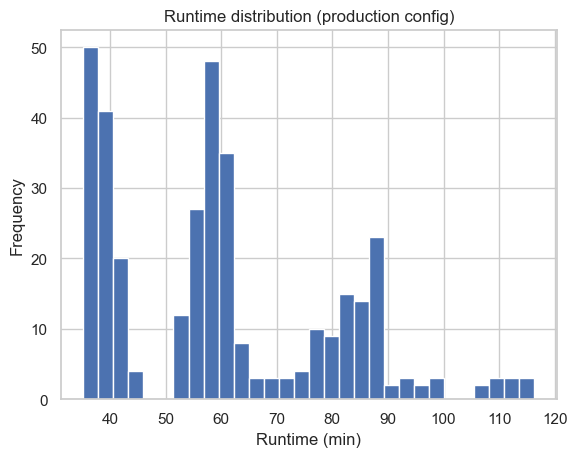

In [13]:
df_clean.runtime_seconds.div(60).plot.hist(bins=30)
plt.xlabel("Runtime (min)")
plt.title("Runtime distribution (production config)")
plt.show()